In [8]:
import numpy as np
from Solver.AdvReactUni import AdvReactUni1DSolver, AdvReactUni1DEval
from Solver.FVUni2nd import FVUni2nd1D
from Solver.ODE import ESDIRK, DITRExp

Nx = 128 * 1
dt = 1 / Nx / 2 / 1 * 4
tEnd = 0.5

fv = FVUni2nd1D(nx=Nx)
ev = AdvReactUni1DEval(
    fv=fv,
    model="bistable",
    params={"a": 0.5, "k": 1000},
)
solver = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("ESDIRK3"))
solverDITR = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

u = np.array([np.sin(fv.xcs * np.pi * 2) * 0.5 + 0.5])

u1_strang = solver.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    mode="strang",
    solve_opts={
        # "max_iter": 50,
        "CFL": 10,
    },
)


iter [2,6], resN [1.0951e-03 / 2.1914e+01]
iter [3,8], resN [5.7609e-04 / 6.8293e+00]
iter [4,6], resN [2.1100e-04 / 1.0058e+01]
iter [2,7], resN [5.8671e-03 / 3.0820e+02]
iter [3,9], resN [4.5189e-03 / 7.6622e+01]
iter [4,7], resN [6.4330e-03 / 1.3770e+02]
iter [2,6], resN [1.3455e-02 / 1.7935e+02]
iter [3,5], resN [5.1261e-04 / 3.8685e+01]
iter [4,5], resN [5.9424e-04 / 5.2139e+01]
iter [2,10], resN [1.8515e-02 / 2.6536e+02]
iter [3,10], resN [5.4738e-03 / 5.9673e+01]
iter [4,10], resN [5.4736e-03 / 6.7764e+01]
Step [1], t = [1.5625e-02] uNorm [7.890111148107104]
iter [2,10], resN [7.8258e-03 / 8.9426e+01]
iter [3,10], resN [1.5532e-02 / 2.4540e+01]
iter [3,14], resN [1.5338e-03 / 2.4540e+01]
iter [4,10], resN [3.7558e-02 / 3.7335e+01]
iter [4,14], resN [3.7161e-03 / 3.7335e+01]
iter [2,7], resN [2.9806e-03 / 9.8996e+01]
iter [3,9], resN [2.2292e-03 / 2.5319e+01]
iter [4,7], resN [3.6698e-03 / 5.2102e+01]
iter [2,6], resN [9.5071e-04 / 7.0896e+01]
iter [3,5], resN [1.0791e-04 / 1.509

In [9]:
u1 = solver.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
)


iter [2,10], resN [7.0857e+00 / 3.0898e+02]
iter [2,16], resN [1.5701e-02 / 3.0898e+02]
iter [3,10], resN [2.2016e-02 / 5.9315e+01]
iter [3,12], resN [3.8629e-03 / 5.9315e+01]
iter [4,10], resN [1.4377e-01 / 1.2175e+02]
iter [4,13], resN [5.3522e-03 / 1.2175e+02]
Step [1], t = [1.5625e-02] uNorm [7.9775722930698665]
iter [2,10], resN [3.9124e+02 / 1.3871e+02]
iter [2,17], resN [8.8569e-03 / 1.3871e+02]
iter [3,10], resN [1.6851e-02 / 2.9225e+01]
iter [3,13], resN [1.7591e-03 / 2.9225e+01]
iter [4,10], resN [1.5020e-01 / 8.0928e+01]
iter [4,15], resN [5.4007e-03 / 8.0928e+01]
Step [2], t = [3.1250e-02] uNorm [7.9601753888758555]
iter [2,10], resN [8.6377e+01 / 1.2896e+02]
iter [2,17], resN [7.0189e-03 / 1.2896e+02]
iter [3,10], resN [1.4330e-02 / 2.5661e+01]
iter [3,13], resN [1.7434e-03 / 2.5661e+01]
iter [4,10], resN [2.1074e-01 / 8.0417e+01]
iter [4,17], resN [4.6534e-03 / 8.0417e+01]
Step [3], t = [4.6875e-02] uNorm [7.964677585093628]
iter [2,10], resN [1.2129e+01 / 1.2791e+02]
ite

In [10]:
u1Ditr = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
    use_exp=True,
)

/home/harry/projects/reactionTest/reactionTest/Solver/AdvReactUni.py:101: RuntimeWarning: overflow encountered in multiply
  return u * (1 - u) * (u - a) * k
/home/harry/projects/reactionTest/reactionTest/Solver/AdvReactUni.py:90: RuntimeWarning: invalid value encountered in subtract
  df = 0.5 * an * (duRecN) - 0.5 * abs(an) * (duRecN)
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:31: RuntimeWarning: invalid value encountered in subtract
  du = uN - u
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:46: RuntimeWarning: invalid value encountered in subtract
  alphaBJMax = np.minimum(np.abs(uMax - u) / (np.abs(uRecMax) + 1e-300), 1.0)
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:46: RuntimeWarning: invalid value encountered in divide
  alphaBJMax = np.minimum(np.abs(uMax - u) / (np.abs(uRecMax) + 1e-300), 1.0)
/home/harry/projects/reactionTest/reactionTest/Solver/FVUni2nd.py:47: RuntimeWarning: invalid value encountered in subtra

iter [[0.5, 1],10], resN [nan / 1.2986e+07]
iter [[0.5, 1],20], resN [nan / 1.2986e+07]
iter [[0.5, 1],30], resN [nan / 1.2986e+07]
iter [[0.5, 1],40], resN [nan / 1.2986e+07]
iter [[0.5, 1],50], resN [nan / 1.2986e+07]
iter [[0.5, 1],60], resN [nan / 1.2986e+07]
iter [[0.5, 1],70], resN [nan / 1.2986e+07]
iter [[0.5, 1],80], resN [nan / 1.2986e+07]
iter [[0.5, 1],90], resN [nan / 1.2986e+07]
iter [[0.5, 1],100], resN [nan / 1.2986e+07]
iter [[0.5, 1],110], resN [nan / 1.2986e+07]
iter [[0.5, 1],120], resN [nan / 1.2986e+07]
iter [[0.5, 1],130], resN [nan / 1.2986e+07]
iter [[0.5, 1],140], resN [nan / 1.2986e+07]
iter [[0.5, 1],150], resN [nan / 1.2986e+07]
iter [[0.5, 1],160], resN [nan / 1.2986e+07]
iter [[0.5, 1],170], resN [nan / 1.2986e+07]
iter [[0.5, 1],180], resN [nan / 1.2986e+07]
iter [[0.5, 1],190], resN [nan / 1.2986e+07]
iter [[0.5, 1],200], resN [nan / 1.2986e+07]
iter [[0.5, 1],210], resN [nan / 1.2986e+07]
iter [[0.5, 1],220], resN [nan / 1.2986e+07]
iter [[0.5, 1],230]

KeyboardInterrupt: 

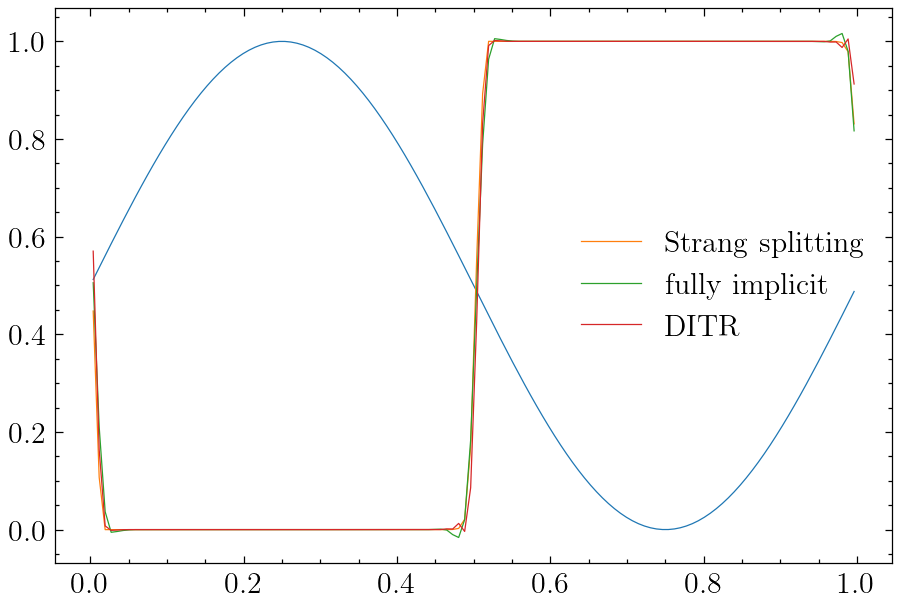

In [ ]:
import matplotlib.pyplot as plt
import PlotEnv

plotEnv = PlotEnv.PlotEnv(dpi=180, markEvery=0)

fig = plotEnv.figure(101, figsize=(6, 4))
plotEnv.plot(fv.xcs, u[0], plotIndex=0)
plotEnv.plot(fv.xcs, u1_strang[0], plotIndex=1, label="Strang splitting")
plotEnv.plot(fv.xcs, u1[0], plotIndex=2, label="fully implicit")
plotEnv.plot(fv.xcs, u1Ditr[0], plotIndex=3, label="DITR")
plt.legend()
plt.show()